In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import sunpy
import sunpy.map
from sunpy.coordinates import get_earth
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
import astropy.units as u
import astropy.constants as const
from ndcube import NDCube
from scipy.io import readsav
from skimage import measure
import skimage.measure.profile
import matplotlib.lines as mlines
from matplotlib.patches import Polygon
from sunpy.coordinates import get_earth

In [2]:
slit_coordinates_sav = readsav("../../sav/slit_locations.sav", verbose=True)

--------------------------------------------------
Date: Thu Nov 14 10:08:50 2024
User: mandal
Host: Mansu-SL22
--------------------------------------------------
Format: 12
Architecture: x86_64
Operating System: linux
IDL Version: 8.5.1
--------------------------------------------------
Successfully read 7 records of which:
 - 4 are of type VARIABLE
 - 1 are of type VERSION
 - 1 are of type TIMESTAMP
--------------------------------------------------
Available variables:
 - slit1 [<class 'numpy.ndarray'>]
 - slit2 [<class 'numpy.ndarray'>]
 - slit3 [<class 'numpy.ndarray'>]
 - slit4 [<class 'numpy.ndarray'>]
--------------------------------------------------


In [3]:
file_Hbeta_pr = h5py.File("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

In [4]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)
cdelt_rebin = dkist_vbi_target_header["CDELT1"]*4

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((4,4))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [5]:
Hbeta_pr_rebin = np.nanmean(Hbeta_pr_da.reshape([Hbeta_pr_da.shape[0],
                    Hbeta_pr_da.shape[1]//4, 4,
                    Hbeta_pr_da.shape[2]//4, 4]), axis=(2,4))
Hbeta_pr_rebin = Hbeta_pr_rebin.compute()

In [7]:
Halpha_date_obs = Time(ascii.read("/cluster/home/zhuyin/work/dkist_solo_fibril_data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])
halpha_select_index = 312
select_index = np.argmin(np.abs(Halpha_date_obs[halpha_select_index] - Hbeta_date_obs))

In [15]:
Hbeta_std = np.std(Hbeta_pr_rebin, axis=(1,2))

In [16]:
print(np.arange(195,205), Hbeta_std[np.arange(195,205)])

[195 196 197 198 199 200 201 202 203 204] [0.24138754 0.23040538 0.21990893 0.21678789 0.21229699 0.2199079
 0.20791327 0.19925293 0.20367918 0.20766742]


In [24]:
print(select_index)
select_index = 195
Hbeta_map_example = Hbeta_pr_rebin[select_index,:,:]

202


In [25]:
def get_profile_intensity(x_select, y_select, smap=Hbeta_map_example, linewidth=8*2):
    pixels_idy, pixels_idx = measure.profile._line_profile_coordinates((y_select[0], x_select[0]),
                            (y_select[1], x_select[1]), linewidth=linewidth)

    pixels_idy_center = np.nanmean(pixels_idy,axis=1)
    pixels_idx_center = np.nanmean(pixels_idx,axis=1)

    pixel_distance = np.cumsum(np.sqrt(np.diff(pixels_idx_center)**2 + np.diff(pixels_idy_center)**2))
    pixel_distance = np.insert(pixel_distance,0,0)
    
    pixel_perp_distance = np.sqrt(np.nanmean(np.diff(pixels_idx, axis=1))**2 + \
                                  np.nanmean(np.diff(pixels_idy, axis=1))**2)
    
    pixel_prep_distance = np.arange(pixels_idy.shape[1])*pixel_perp_distance

    intensity =  measure.profile_line(smap, 
                                    (y_select[0], x_select[0]), (y_select[1], x_select[1]),
                                    linewidth=linewidth,
                                    reduce_func=None)

    return intensity, pixel_distance, pixel_prep_distance, pixels_idx, pixels_idy

In [26]:
def plot_slit_position(pixels_idx, pixels_idy, ax1, triangle_length=80, triangle_anchor_index=160, triangle_ratio=0.6,
                       color='#58B2DC', lw=1, alpha=0.5, text=None, text_color=None, text_offset=5, text_fontsize=10):
    boundary_x = np.concatenate((pixels_idx[:, 0], pixels_idx[-1, 1:], pixels_idx[-1::-1, -1], pixels_idx[0, -1::-1]))
    boundary_y = np.concatenate((pixels_idy[:, 0], pixels_idy[-1, 1:], pixels_idy[-1::-1, -1], pixels_idy[0, -1::-1]))

    slit_boundary_collection = []
    boundary_x_line2d_ax1 = mlines.Line2D(boundary_x, boundary_y, color=color, lw=lw, alpha=alpha)
    boundary_x_line2d_ax2 = mlines.Line2D(boundary_x, boundary_y, color=color, lw=lw, alpha=alpha)
    slit_boundary_collection.append(ax1.add_line(boundary_x_line2d_ax1))

    triangle_anchor_point_0 = np.array([pixels_idx[triangle_anchor_index, 0], pixels_idy[triangle_anchor_index, 0]])
    triangle_anchor_point_1 = np.array([pixels_idx[triangle_anchor_index + triangle_length, 0], pixels_idy[triangle_anchor_index + triangle_length, 0]])
    triangle_bottom_vec = triangle_anchor_point_1 - triangle_anchor_point_0
    triangle_bottom_vec_rot_90 = np.array([triangle_bottom_vec[1], -triangle_bottom_vec[0]])*triangle_ratio
    triangle_anchor_point_2 = triangle_anchor_point_0 + triangle_bottom_vec_rot_90

    triangle_points = np.vstack((triangle_anchor_point_0, triangle_anchor_point_1, triangle_anchor_point_2,))
    
    for ax_ in (ax1,):
        triangle_patch = Polygon(triangle_points, closed=True, edgecolor=color, facecolor=color, alpha=alpha)
        ax_.add_patch(triangle_patch)

    if text is not None:
        if text_color is None:
            text_color = color
        slit_center_x = np.nanmean(pixels_idx)
        slit_center_y = np.nanmean(pixels_idy)
        triangle_bottom_vec_rot_90_norm = triangle_bottom_vec_rot_90/np.linalg.norm(triangle_bottom_vec_rot_90)

        for ax_ in (ax1,):
            ax_.text(slit_center_x + text_offset*triangle_bottom_vec_rot_90_norm[0], 
                     slit_center_y + text_offset*triangle_bottom_vec_rot_90_norm[1], text,
                    color=text_color, fontsize=text_fontsize, ha='center', va='center',
                    )


    return slit_boundary_collection

In [27]:
x_select_all = [[536.8,487.1],[465.3,382.2],[371.6,260.0],[359.0,298],
[363,271],[72,42],[184,135],[615,625],[613,575],[393,227]]
y_select_all = [[328.8,260.5],[487.4,470.2],[493.4,417.8],[407.4,337],
[844,858],[631,536],[613,500],[355,260],[578,669],[716,775]]

intensity_all = []
pixel_distance_all = []
pixel_prep_distance_all = []
pixels_idx_all = []
pixels_idy_all = []

earth_coords = get_earth(dkist_vbi_target_header["DATE-AVG"])

delta_pixel = np.deg2rad(cdelt_rebin/3600)*earth_coords.radius.to_value(u.Mm)

for x_select_, y_select_ in zip(x_select_all, y_select_all):
    intensity_, pixel_distance_, pixel_prep_distance_, pixels_idx_, pixels_idy_ = get_profile_intensity(x_select_, y_select_,
    linewidth=25)
    intensity_all.append(intensity_)
    pixel_distance_all.append(pixel_distance_*delta_pixel)
    pixel_prep_distance_all.append(pixel_prep_distance_*delta_pixel)
    pixels_idx_all.append(pixels_idx_)
    pixels_idy_all.append(pixels_idy_)


In [28]:
# %matplotlib ipympl 

# fig_test, ax_test = plt.subplots(figsize=(8,8))
# ax_test.imshow(Hbeta_map_example, origin="lower", cmap="gray", interpolation="none",
#           norm=ImageNormalize(vmin=0, vmax=0.9))
# # plt.show()

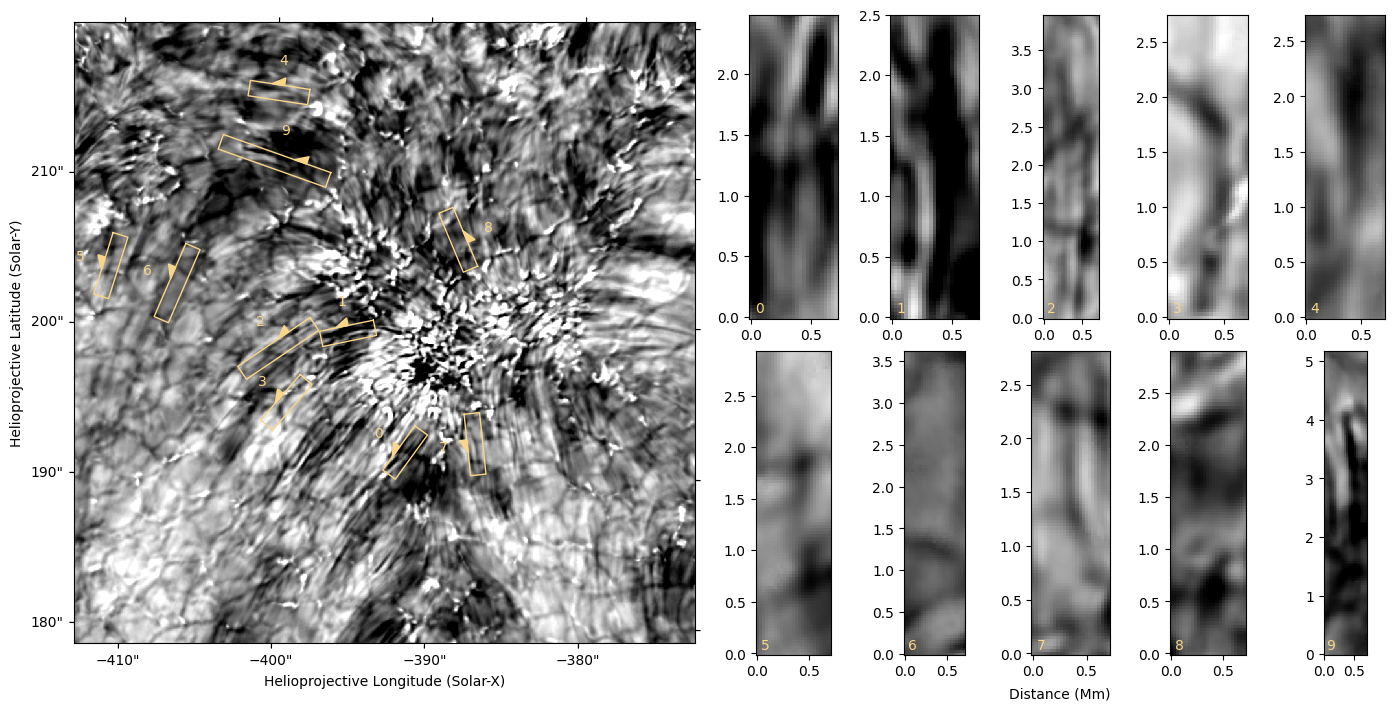

In [29]:
%matplotlib inline

fig = plt.figure(figsize=(14,7), layout="constrained")
fig_left, fig_right = fig.subfigures(1, 2, wspace=0.02)

ax_vbi = fig_left.add_subplot(111, projection=dkist_vbi_target_cube_crop_rebin.wcs)
ax_vbi.imshow(Hbeta_map_example, origin="lower", cmap="gray", interpolation="none",
          norm=ImageNormalize(vmin=0, vmax=0.9))
ax_vbi.set_xlabel("Helioprojective Longitude (Solar-X)")
ax_vbi.set_ylabel("Helioprojective Latitude (Solar-Y)")

for ii in range(len(intensity_all)):
    ax_ = fig_right.add_subplot(2,5,ii+1)
    ax_.pcolormesh(pixel_prep_distance_all[ii], pixel_distance_all[ii], intensity_all[ii],
                   cmap="gray", norm=ImageNormalize(vmin=0, vmax=0.9),
                   shading="auto")
    
    ax_.set_aspect("equal")
    
    plot_slit_position(pixels_idx_all[ii], pixels_idy_all[ii], ax_vbi, text=f"{ii}", 
    triangle_length=20, triangle_anchor_index=40, text_offset=50, alpha=1, color="#FAD689")

    ax_.text(0.07, 0.01, f"{ii}", transform=ax_.transAxes,
             fontsize=10, color="#FAD689", va="bottom", ha="left")
    # imshow(intensity_all[ii], origin="lower", cmap="gray", interpolation="none",
    #           norm=ImageNormalize(vmin=0, vmax=0.9)) 
fig_right.supxlabel('Distance (Mm)',fontsize=10)   
fig.savefig("../../figs/test_figs/Hbeta_fibril_example.png",dpi=300, bbox_inches="tight")
plt.show()
